In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("asaniczka/uk-optimal-product-price-prediction")

print("Path to dataset files:", path)

100%|██████████| 117M/117M [00:04<00:00, 28.9MB/s] 

Extracting files...


Path to dataset files: C:\Users\tachi\.cache\kagglehub\datasets\asaniczka\uk-optimal-product-price-prediction\versions\3


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("amz_uk_price_prediction_dataset.csv")

In [3]:
df

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers
...,...,...,...,...,...,...,...,...,...
2443646,2828589,B0CHSD7P2Q,"Motorbike Armour, Motorbike Clothing, Cycling ...",0.0,0,22.34,False,0,Motorbike Clothing
2443647,2828590,B0B7B8FNBQ,PROFIRST Waterproof Motorcycle 2 Piece Ladies ...,0.0,0,97.99,False,0,Motorbike Clothing
2443648,2828591,B0BD5FL5FB,Men’s Motorcycle Motorbike Biker Trousers Kevl...,0.0,0,52.99,False,0,Motorbike Clothing
2443649,2828592,B008OYLL4I,Texpeed Mens Motorcycle Motorbike Biker Trouse...,4.3,404,79.99,False,0,Motorbike Clothing


In [6]:
df['category'].value_counts()

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Motorbike Chassis                            107
Alexa Built-In Devices                       107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

In [ ]:

frecuencia_cat = df['category'].value_counts().reset_index()
frecuencia_cat.columns = ['Categoría', 'Frecuencia']


frecuencia_cat


,Categoría,Frecuencia
0,Sports & Outdoors,836265
1,Beauty,19312
2,"Handmade Clothing, Shoes & Accessories",19229
3,Bath & Body,19092
4,Birthday Gifts,18978
...,...,...
291,Motorbike Chassis,107
292,Alexa Built-In Devices,107
293,Plugs,107
294,Smart Home Security & Lighting,104


In [13]:
frecuencia_cat.sort_values(by='Frecuencia', ascending=False)

,Categoría,Frecuencia
0,Sports & Outdoors,836265
1,Beauty,19312
2,"Handmade Clothing, Shoes & Accessories",19229
3,Bath & Body,19092
4,Birthday Gifts,18978
...,...,...
291,Motorbike Chassis,107
292,Alexa Built-In Devices,107
293,Plugs,107
294,Smart Home Security & Lighting,104


In [27]:
top5=frecuencia_cat.head(5)

In [28]:
top5

,Categoría,Frecuencia
0,Sports & Outdoors,836265
1,Beauty,19312
2,"Handmade Clothing, Shoes & Accessories",19229
3,Bath & Body,19092
4,Birthday Gifts,18978


Las más cotizadas son Sport, Beauty, Handmade Clothing, Bath & Body y Brithday Gifts.

actividad 2

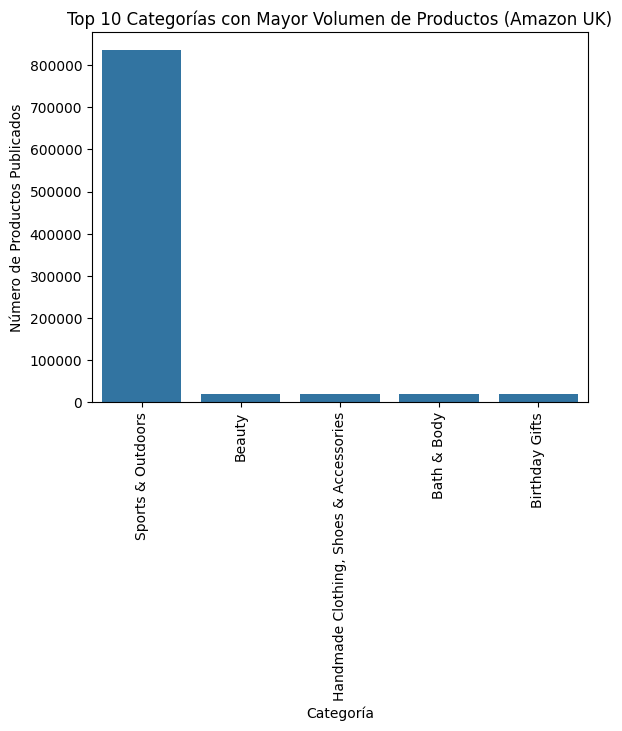

In [29]:

sns.barplot(data=top5, x='Categoría', y='Frecuencia')
plt.xticks(rotation=90)
plt.title('Top 10 Categorías con Mayor Volumen de Productos (Amazon UK)')
plt.ylabel('Número de Productos Publicados')
plt.xlabel('Categoría')
plt.show()


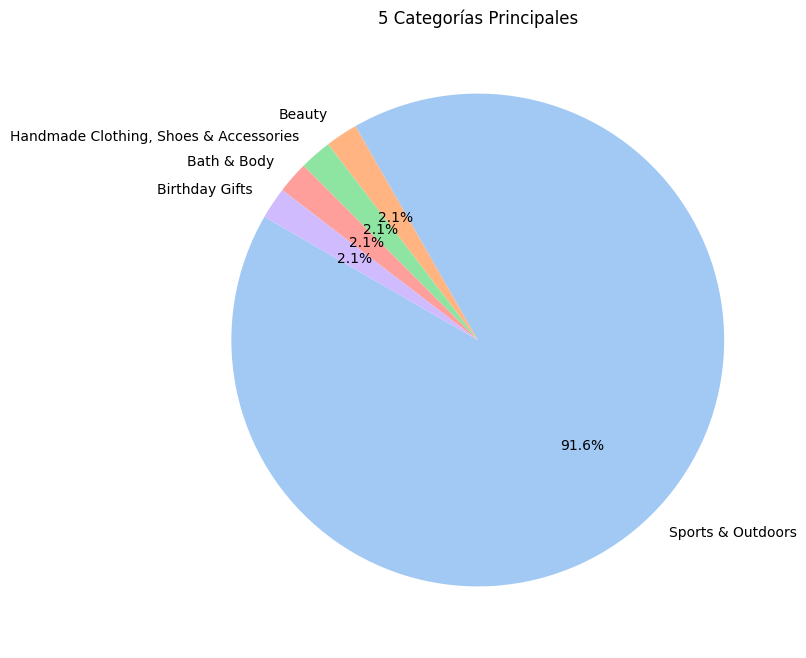

In [37]:
plt.figure(figsize=(8, 8))
plt.pie(top5['Frecuencia'], 
        labels=top5['Categoría'], 
        autopct='%1.1f%%', 
        startangle=150, 
        colors=sns.color_palette('pastel'))
plt.title('5 Categorías Principales')
plt.show()


Predomina con un 91,6% los productos de Sport & Outdoors.

Parte 2: Profundizando en el precio del producto
Pregunta comercial : ¿Cómo se fijan los precios de los productos en Amazon Reino Unido? ¿Hay rangos o puntos de precio específicos que sean más comunes?

In [41]:
df['price'].describe()

count    2.443651e+06
mean     8.924381e+01
std      3.456089e+02
min      0.000000e+00
25%      9.990000e+00
50%      1.909000e+01
75%      4.599000e+01
max      1.000000e+05
Name: price, dtype: float64

In [38]:

print(f"Media: {df['price'].mean()}")
print(f"Mediana: {df['price'].median()}")
print(f"Moda: {df['price'].mode()[0]}")


Media: 89.24380943923661
Mediana: 19.09
Moda: 9.99


El precio promedio es de 89,24 libras comparado con la moda que es de 9.99 libras.

array([[<Axes: title={'center': 'uid'}>,
        <Axes: title={'center': 'stars'}>],
       [<Axes: title={'center': 'reviews'}>,
        <Axes: title={'center': 'price'}>],
       [<Axes: title={'center': 'boughtInLastMonth'}>, <Axes: >]],
      dtype=object)

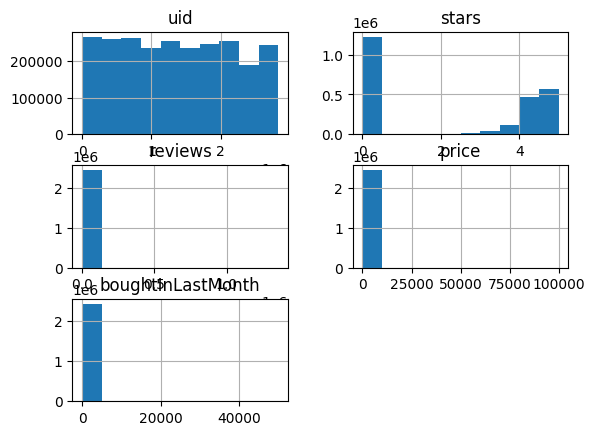

In [44]:
df.hist()

In [45]:

print(f"Desviación Estándar: {df['price'].std()}")
print(f"Rango Intercuartílico: {df['price'].quantile(0.75) - df['price'].quantile(0.25)}")
print(f"Rango: {df['price'].max() - df['price'].min()}")
print(f"Varianza: {df['price'].var()}")


Desviación Estándar: 345.60886175349873
Rango Intercuartílico: 36.0
Rango: 100000.0
Varianza: 119445.48532254901


Observamos que hay una variación muy grande en los precios de los productos. El rango es de 0 a 10000 libras.Además la desviación estándar es de 345.61 aprox. Hay precios muy bajos y muy altos.

In [54]:
df['price'].value_counts().sort_index()

price
0.00          20
0.01         694
0.02           7
0.03           2
0.04          13
            ... 
22933.42       1
23482.73       1
24674.59       1
77752.00       1
100000.00      1
Name: count, Length: 82916, dtype: int64

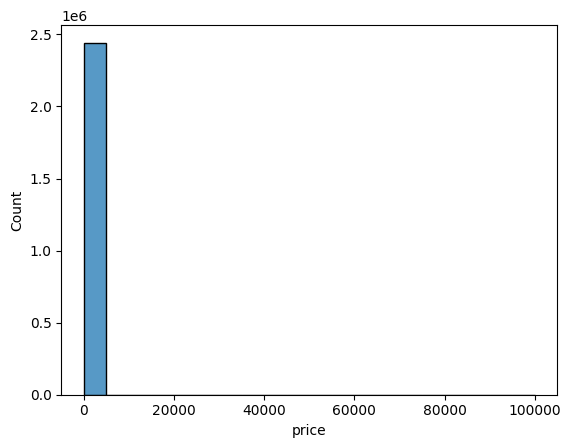

In [48]:
sns.histplot(df['price'], bins=20)
plt.show()


La mayoria de los productos son más bajos al observar el histograma vemos que son precios más bajos. Se debe acotar y analizar los productos con precios muy altos que la media y También los más bajos.

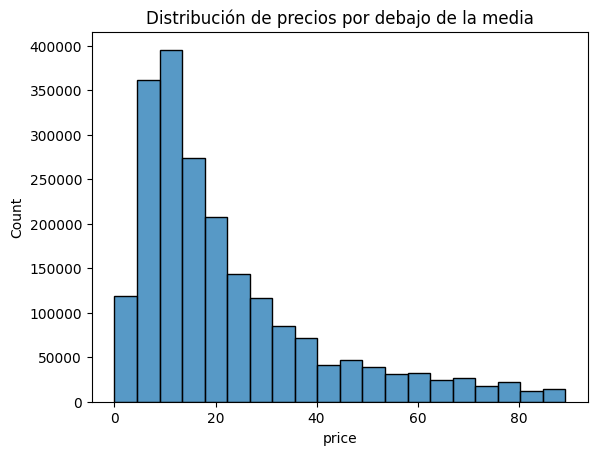

In [50]:
sns.histplot(df['price'][df['price']<df['price'].mean()], bins=20)
plt.title('Distribución de precios por debajo de la media')
plt.show()

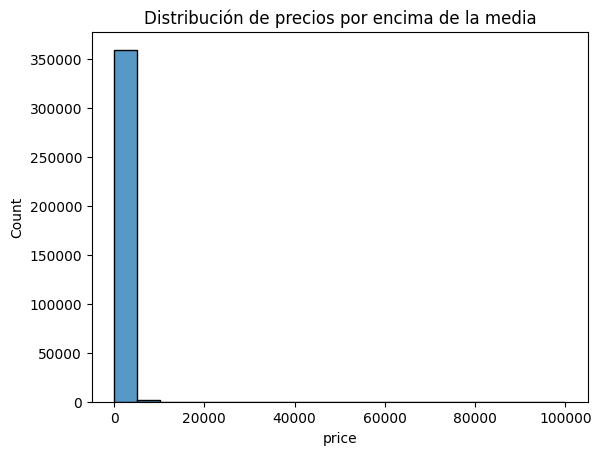

In [51]:
sns.histplot(df['price'][df['price']>df['price'].mean()], bins=20)
plt.title('Distribución de precios por encima de la media')
plt.show()

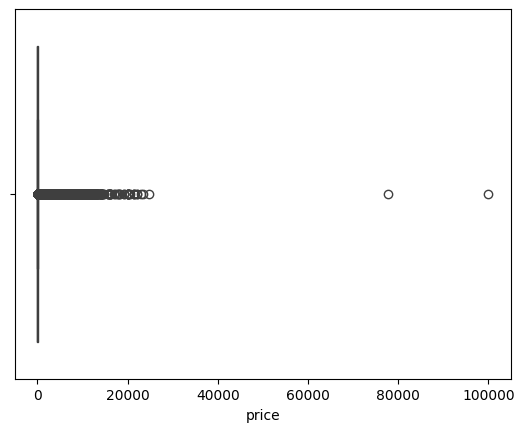

In [58]:

sns.boxplot(x=df['price'])
plt.show()

In [60]:
df['price_quantile'] = pd.qcut(df['price'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

df.price_quantile.value_counts()

price_quantile
Q1    629239
Q3    612341
Q4    609043
Q2    593028
Name: count, dtype: int64

Podemos ver que hay muchos valores atípicos en los precios. Esto se debe a que hay productos con precios muy altos que no son representativos de la mayoría de los productos.

Analizaremos los clientes por su rating de valorización

In [62]:
media_rating = df['stars'].mean()
mediana_rating = df['stars'].median()
moda_rating = df['stars'].mode()[0]


In [64]:
df['stars'].value_counts()

stars
0.0    1225641
4.5     151577
4.6     136995
4.4     136165
5.0     128492
4.3     112564
4.7      94566
4.2      86871
4.0      66089
4.1      65115
4.8      41858
3.9      36555
3.8      27876
3.7      21137
3.6      16219
3.5      14673
3.0      12819
4.9      11081
3.4      10355
1.0       8484
3.3       8269
3.2       5771
3.1       4679
2.0       3901
2.9       3341
2.8       2306
2.7       2104
2.5       2103
2.6       1579
2.4       1060
2.3        734
2.2        602
2.1        540
1.5        404
1.9        300
1.8        249
1.7        177
1.4        149
1.6        147
1.3         78
1.2         23
1.1          3
Name: count, dtype: int64

In [63]:
print(f"Media: {media_rating}")
print(f"Mediana: {mediana_rating}")
print(f"Moda: {moda_rating}")

Media: 2.152836472966066
Mediana: 0.0
Moda: 0.0


Los clientes tienden a no valorizar los productos dejando sin stars, haciendo complejo el estudio.

In [70]:
print(f"Varianza: {df["stars"].var()}")
print(f"Desviación estándar: {df["stars"].std()}")
print(f"Rango: {df["stars"].max() - df["stars"].min()}")
print(f"Rango Intercuartil: {df["stars"].quantile(0.75) - df["stars"].quantile(0.25)}")

Varianza: 4.817434029796864
Desviación estándar: 2.194865378513421
Rango: 5.0
Rango Intercuartil: 4.4


In [72]:
%pip install scipy

   ---------------------------------------- 0.0/36.3 MB ? eta -:--:--
   --------- ------------------------------ 8.4/36.3 MB 46.0 MB/s eta 0:00:01
   ---------------------- ----------------- 20.2/36.3 MB 50.9 MB/s eta 0:00:01
   ---------------------------------- ----- 31.7/36.3 MB 51.8 MB/s eta 0:00:01
   ---------------------------------------  36.2/36.3 MB 52.4 MB/s eta 0:00:01
   ---------------------------------------- 36.3/36.3 MB 43.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [73]:
from scipy.stats import skew, kurtosis

asimetria = skew(df['stars'].dropna())
curtosis_val = kurtosis(df['stars'].dropna())

print(f"Asimetría: {asimetria:.2f}")
print(f"Curtosis: {curtosis_val:.2f}")


Asimetría: 0.08
Curtosis: -1.93


los datos tienden a la derecha (sesgo positivo). Pero tenemos muchos valores en 5 estrellas, lo que indica que hay muchos clientes satisfechos y a la vez la mayoría no valorizó los productos.

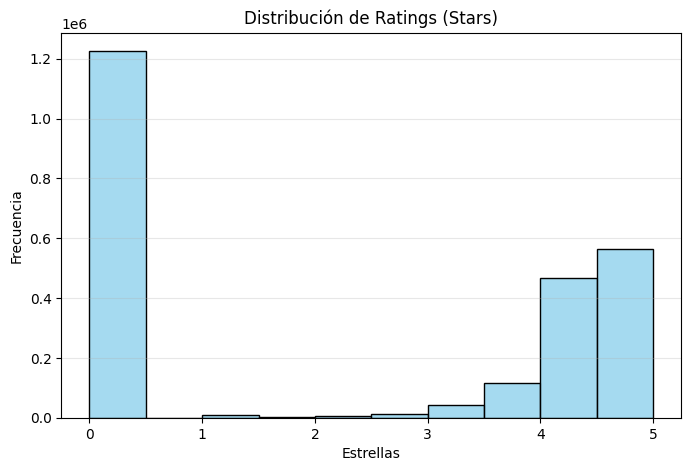

In [78]:
plt.figure(figsize=(8, 5))
sns.histplot(df['stars'], bins=10, color='skyblue')
plt.title('Distribución de Ratings (Stars)')
plt.xlabel('Estrellas')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.show()

La calificación más común es 0 estrellas, lo que indica que muchos clientes no valorizaron los productos.